# Isolator comparison: forward power, 2-3 GHz

Same forward-power sweep (analyzer on the coupler's forward port), run once with an isolator inserted before the bidirectional coupler and once without, to check whether the isolator meaningfully changes what's measured. Both sweeps: 2-3 GHz, 1 MHz steps, -20 dBm source.

Re-run the two sweep cells below to regenerate `data/forward_power_sweep_2-3GHz_1MHz.csv` and `data/no_isolator_sweep_2-3GHz_1MHz.csv` from scratch; the comparison cell at the bottom just loads whatever's currently in `data/`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep

START_HZ = 2.0e9
STOP_HZ = 3.0e9
STEP_HZ = 1e6
POWER_DBM = -20

## With isolator

In [ ]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

with_iso_freqs_hz, with_iso_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

np.savetxt(
    "data/forward_power_sweep_2-3GHz_1MHz.csv",
    np.column_stack((with_iso_freqs_hz, with_iso_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(with_iso_freqs_hz)} points collected")

## Without isolator

In [ ]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

no_iso_freqs_hz, no_iso_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

np.savetxt(
    "data/no_isolator_sweep_2-3GHz_1MHz.csv",
    np.column_stack((no_iso_freqs_hz, no_iso_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(no_iso_freqs_hz)} points collected")

## Comparison

Loads whatever is currently saved in `data/` -- doesn't require re-running the sweeps above.

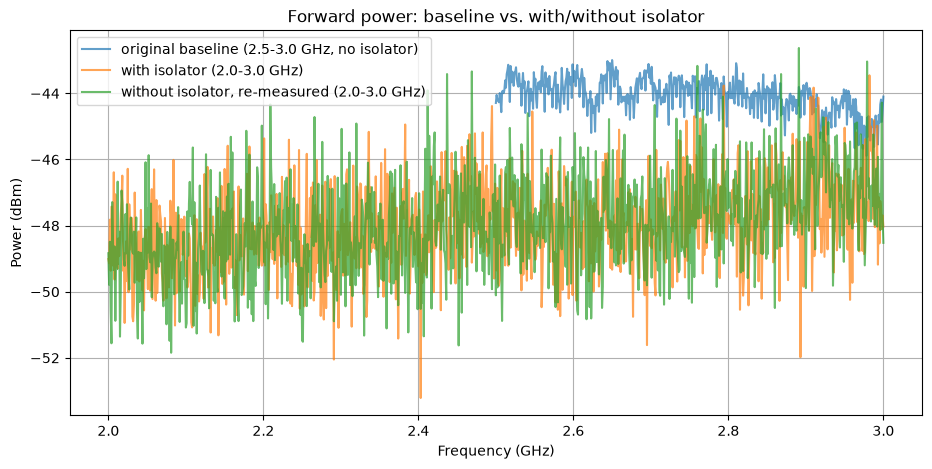

with isolator:    median -48.035 min -53.214 max -43.454
without isolator: median -48.054 min -51.845 max -42.628
mean abs diff (with vs without isolator): 1.4380669330669331 dB


In [1]:
baseline = np.loadtxt("data/frequency_sweep_2.5-3.0GHz_1MHz.csv", delimiter=",", skiprows=1)
with_iso = np.loadtxt("data/forward_power_sweep_2-3GHz_1MHz.csv", delimiter=",", skiprows=1)
no_iso = np.loadtxt("data/no_isolator_sweep_2-3GHz_1MHz.csv", delimiter=",", skiprows=1)

bf, bp = baseline[:, 0], baseline[:, 1]
wf, wp = with_iso[:, 0], with_iso[:, 1]
nf, np_ = no_iso[:, 0], no_iso[:, 1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(bf / 1e9, bp, label="original baseline (2.5-3.0 GHz, no isolator)", alpha=0.7)
ax.plot(wf / 1e9, wp, label="with isolator (2.0-3.0 GHz)", alpha=0.7)
ax.plot(nf / 1e9, np_, label="without isolator, re-measured (2.0-3.0 GHz)", alpha=0.7)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Power (dBm)")
ax.set_title("Forward power: baseline vs. with/without isolator")
ax.legend()
ax.grid(True)
plt.show()

print("with isolator:    median", np.median(wp), "min", wp.min(), "max", wp.max())
print("without isolator: median", np.median(np_), "min", np_.min(), "max", np_.max())
print("mean abs diff (with vs without isolator):", np.mean(np.abs(wp - np_)), "dB")